In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/plant-leaves-super-resolution-challenge/sample_submission.csv
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/vgg19_weights.pth
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/agrivision_train_0772.png
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/agrivision_train_0802.png
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/agrivision_train_1205.png
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/agrivision_train_1566.png
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/agrivision_train_0518.png
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/agrivision_train_0276.png
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/agrivision_train_0497.png
/kaggle/input/competitions/p

## 1. Importing libraries

In [2]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Variable
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

##### Verify PyTorch installation

In [3]:
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.10.0+cu128
CUDA Available: True
CUDA Version: 12.8
GPU Device: Tesla T4


##### Create directory for saving samples

In [4]:
sample_dir = 'samples'
if not os.path.exists(sample_dir):
    os.makedirs(sample_dir)
    print(f"Created directory: {sample_dir}")

Created directory: samples


## 2. Hyperparameter Configuration

##### Image specifications

In [5]:
LR_SIZE    = 32          # Low-resolution input size
HR_SIZE    = 128         # High-resolution output size
LR_PIXELS  = LR_SIZE * LR_SIZE * 3     # 3072  (flattened LR)
HR_PIXELS  = HR_SIZE * HR_SIZE * 3     # 49152 (flattened HR)

##### Neural Network Architecture

In [6]:
hidden_size = 1024

##### Training Configurations

In [7]:
num_epochs  = 100        
batch_size  = 64       
lr          = 0.0002   
betas       = (0.5, 0.999)  # Adam betas

print("=" * 70)
print("cGAN HYPERPARAMETER CONFIGURATION")
print("=" * 70)
print(f"LR Image Size:          {LR_SIZE}x{LR_SIZE}x3 = {LR_PIXELS} pixels")
print(f"HR Image Size:          {HR_SIZE}x{HR_SIZE}x3 = {HR_PIXELS} pixels")
print(f"Hidden Layer Size:      {hidden_size}")
print(f"Training Epochs:        {num_epochs}")
print(f"Batch Size:             {batch_size}")
print(f"Learning Rate:          {lr}")
print("=" * 70)

cGAN HYPERPARAMETER CONFIGURATION
LR Image Size:          32x32x3 = 3072 pixels
HR Image Size:          128x128x3 = 49152 pixels
Hidden Layer Size:      1024
Training Epochs:        100
Batch Size:             64
Learning Rate:          0.0002


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nCompute Device: {device}")
if device.type == 'cuda':
    print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Compute Device: cuda
GPU Memory Available: 15.64 GB


## 3. DATA PREPARATION AND LOADING

In [9]:
 
class SuperResDataset(Dataset):
    
    def __init__(self, lr_dir, hr_dir=None, is_test=False):
        self.lr_dir   = lr_dir
        self.hr_dir   = hr_dir
        self.is_test  = is_test
        self.filenames = sorted(os.listdir(lr_dir))
 
        self.transform = transforms.Compose([
            transforms.ToTensor(),                      
            transforms.Normalize(mean=[0.5, 0.5, 0.5],  
                                 std=[0.5, 0.5, 0.5])
        ])
 
    def __len__(self):
        return len(self.filenames)
 
    def __getitem__(self, idx):
        fname  = self.filenames[idx]
        lr_img = Image.open(os.path.join(self.lr_dir, fname)).convert('RGB')
        lr_tensor = self.transform(lr_img)   # shape: (3, 32, 32)
 
        if self.is_test:
            return lr_tensor, fname
 
        hr_img = Image.open(os.path.join(self.hr_dir, fname)).convert('RGB')
        hr_tensor = self.transform(hr_img)   # shape: (3, 128, 128)
        return lr_tensor, hr_tensor

##### Dataset paths

In [10]:
LR_TRAIN = '/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution'
HR_TRAIN = '/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_High_Resolution'
LR_TEST  = '/kaggle/input/competitions/plant-leaves-super-resolution-challenge/test_Low_Resolution'
 
train_dataset = SuperResDataset(LR_TRAIN, HR_TRAIN, is_test=False)
test_dataset  = SuperResDataset(LR_TEST,  is_test=True)

##### Data Loader

In [11]:

data_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True        
)
 
print(f"\nDataset loaded successfully!")
print(f"Total training images: {len(train_dataset)}")
print(f"Batches per epoch:     {len(data_loader)}")
print(f"LR Image shape: (3, {LR_SIZE}, {LR_SIZE})")
print(f"HR Image shape: (3, {HR_SIZE}, {HR_SIZE})")


Dataset loaded successfully!
Total training images: 1642
Batches per epoch:     26
LR Image shape: (3, 32, 32)
HR Image shape: (3, 128, 128)


## 4. MODEL ARCHITECTURE DESIGN

#### 4.1 Generator Network Architecture

In [12]:
class Generator(nn.Module):
    
    def __init__(self, input_size, hidden_size, output_size):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            # Layer 1: LR features
            nn.Linear(input_size, hidden_size),
            nn.LeakyReLU(0.2),                     
            
            # Layer 2: intermediate representation
            nn.Linear(hidden_size, hidden_size * 2),
            nn.LayerNorm(hidden_size * 2),
            nn.LeakyReLU(0.2),
 
            # Layer 3: richer features
            nn.Linear(hidden_size * 2, hidden_size * 4),
            nn.LayerNorm(hidden_size * 4),
            nn.LeakyReLU(0.2),
 
            # Layer 4: expand towards HR
            nn.Linear(hidden_size * 4, hidden_size * 2),
            nn.LayerNorm(hidden_size * 2),
            nn.LeakyReLU(0.2),
 
            # Output: HR image pixels 
            nn.Linear(hidden_size * 2, output_size),
            nn.Tanh()                               
        )
 
    def forward(self, x):
        
        return self.model(x)

#### 4.2 Discriminator Network Architecture

In [13]:
class Discriminator(nn.Module):
    
    def __init__(self, input_size, hidden_size):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            # Input: LR condition + HR image concatenated
            nn.Linear(input_size, hidden_size * 2),
            nn.LeakyReLU(0.2),                   
 
            nn.Linear(hidden_size * 2, hidden_size),
            nn.LeakyReLU(0.2),
 
            nn.Linear(hidden_size, hidden_size // 2),
            nn.LeakyReLU(0.2),
 
            # Output: single real/fake score (same Sigmoid as course)
            nn.Linear(hidden_size // 2, 1),
            nn.Sigmoid()                          
        )
 
    def forward(self, lr, hr):
        
        x = torch.cat([lr, hr], dim=1)   # Concatenate condition + image
        return self.model(x)

##### Instantiate Network

In [14]:
generator     = Generator(LR_PIXELS, hidden_size, HR_PIXELS).to(device)
discriminator = Discriminator(LR_PIXELS + HR_PIXELS, hidden_size).to(device)
 
print("\n" + "=" * 70)
print("GENERATOR ARCHITECTURE")
print("=" * 70)
print(generator)
print("=" * 70)
print(f"Total Parameters: {sum(p.numel() for p in generator.parameters()):,}")
print("=" * 70)
 
print("\n" + "=" * 70)
print("DISCRIMINATOR ARCHITECTURE")
print("=" * 70)
print(discriminator)
print("=" * 70)
print(f"Total Parameters: {sum(p.numel() for p in discriminator.parameters()):,}")
print("=" * 70)


GENERATOR ARCHITECTURE
Generator(
  (model): Sequential(
    (0): Linear(in_features=3072, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=1024, out_features=2048, bias=True)
    (3): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Linear(in_features=2048, out_features=4096, bias=True)
    (6): LayerNorm((4096,), eps=1e-05, elementwise_affine=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Linear(in_features=4096, out_features=2048, bias=True)
    (9): LayerNorm((2048,), eps=1e-05, elementwise_affine=True)
    (10): LeakyReLU(negative_slope=0.2)
    (11): Linear(in_features=2048, out_features=49152, bias=True)
    (12): Tanh()
  )
)
Total Parameters: 122,758,144

DISCRIMINATOR ARCHITECTURE
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=52224, out_features=2048, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=2048, out_features=1

In [15]:
test_lr = torch.randn(1, LR_PIXELS).to(device)
test_hr = generator(test_lr)
test_disc = discriminator(test_lr, test_hr)
print(f"\nGenerator Test:")
print(f"Input shape:  {test_lr.shape}")
print(f"Output shape: {test_hr.shape}")
print(f"\nDiscriminator Test:")
print(f"Output shape: {test_disc.shape}")
print(f"Output value: {test_disc.item():.4f} (probability of being real)")


Generator Test:
Input shape:  torch.Size([1, 3072])
Output shape: torch.Size([1, 49152])

Discriminator Test:
Output shape: torch.Size([1, 1])
Output value: 0.4950 (probability of being real)


##  5. TRAINING CONFIGURATION

#### 5.1 Loss Functions and Optimization Strategy

In [16]:
criterion_adv = nn.BCELoss()   # Adversarial loss (same as course)
criterion_l1  = nn.L1Loss()    # Pixel-wise loss → directly minimizes MAE!

##### 5.2 Optimizer Initialization

In [17]:
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=lr, betas=betas)
g_optimizer = torch.optim.Adam(generator.parameters(),     lr=lr, betas=betas)
 
print("\nOptimization Configuration:")
print("Loss Functions: BCE (adversarial) + L1 (pixel fidelity)")
print("Optimizer:      Adam")
print(f"Learning Rate:  {lr}")
print(f"Betas:          {betas}")
print("Separate optimizers for D and G")
 
lambda_l1 = 100 
 


Optimization Configuration:
Loss Functions: BCE (adversarial) + L1 (pixel fidelity)
Optimizer:      Adam
Learning Rate:  0.0002
Betas:          (0.5, 0.999)
Separate optimizers for D and G


#### 5.3 Auxiliary Functions for Training 

In [18]:
def denorm(x):
    out = (x + 1) / 2
    return out.clamp(0, 1)
 
def reset_grad():
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()

## 6. TRAINING LOOP

In [19]:
d_losses = []
g_losses = []
best_g_loss = float('inf')
patience    = 10
no_improve  = 0

print("\n" + "=" * 70)
print("STARTING cGAN TRAINING")
print("=" * 70)

for epoch in range(num_epochs):
    epoch_d_loss = 0
    epoch_g_loss = 0
    total_step   = len(data_loader)

    for step, (lr_imgs, hr_imgs) in enumerate(data_loader):
        lr_imgs = lr_imgs.to(device)
        hr_imgs = hr_imgs.to(device)

        lr_flat = lr_imgs.view(lr_imgs.size(0), -1) 
        hr_flat = hr_imgs.view(hr_imgs.size(0), -1)   

        real_labels = torch.ones(lr_imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(lr_imgs.size(0), 1).to(device)

        # ── TRAIN DISCRIMINATOR ──
        real_score  = discriminator(lr_flat, hr_flat)
        d_loss_real = criterion_adv(real_score, real_labels)

        fake_hr     = generator(lr_flat)
        fake_score  = discriminator(lr_flat, fake_hr.detach())
        d_loss_fake = criterion_adv(fake_score, fake_labels)

        d_loss = (d_loss_real + d_loss_fake) / 2
        reset_grad()
        d_loss.backward()
        d_optimizer.step()

        # ── TRAIN GENERATOR ──
        fake_hr    = generator(lr_flat)
        fake_score = discriminator(lr_flat, fake_hr)

        g_loss_adv = criterion_adv(fake_score, real_labels)
        g_loss_l1  = criterion_l1(fake_hr, hr_flat) * lambda_l1

        g_loss = g_loss_adv + g_loss_l1
        reset_grad()
        g_loss.backward()
        g_optimizer.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()


    avg_d = epoch_d_loss / total_step
    avg_g = epoch_g_loss / total_step
    d_losses.append(avg_d)
    g_losses.append(avg_g)

    
    print(f'Epoch [{epoch+1}/{num_epochs}]  '
          f'D_loss: {avg_d:.4f}  G_loss: {avg_g:.4f}')


    if avg_g < best_g_loss:
        best_g_loss = avg_g
        no_improve  = 0
        torch.save(generator.state_dict(), 'best_generator.pth')
        print(f'Best model saved (G_loss: {best_g_loss:.4f})')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'\nEarly stopping triggered at epoch {epoch+1}')
            break

    if (epoch + 1) % 10 == 0:
        with torch.no_grad():
            sample_lr, sample_hr = next(iter(data_loader))
            sample_lr      = sample_lr[:8].to(device)
            sample_lr_flat = sample_lr.view(sample_lr.size(0), -1)
            fake_sample    = generator(sample_lr_flat)
            fake_sample    = fake_sample.view(-1, 3, HR_SIZE, HR_SIZE)
            torchvision.utils.save_image(
                denorm(fake_sample),
                os.path.join(sample_dir, f'fake_images-{epoch+1}.png')
            )

print("\n" + "=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)
print(f"Final D Loss:   {d_losses[-1]:.4f}")
print(f"Final G Loss:   {g_losses[-1]:.4f}")
print(f"Best G Loss:    {best_g_loss:.4f}")
print("=" * 70)

generator.load_state_dict(torch.load('best_generator.pth'))
print("\nBest model weights loaded for submission!")


torch.save(generator.state_dict(),     'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')
print("Generator weights saved to: generator.pth")
print("Discriminator weights saved to: discriminator.pth")


STARTING cGAN TRAINING
Epoch [1/100]  D_loss: 0.8449  G_loss: 28.7885
Best model saved (G_loss: 28.7885)
Epoch [2/100]  D_loss: 0.6953  G_loss: 24.9585
Best model saved (G_loss: 24.9585)
Epoch [3/100]  D_loss: 0.7016  G_loss: 24.0316
Best model saved (G_loss: 24.0316)
Epoch [4/100]  D_loss: 0.6998  G_loss: 22.9595
Best model saved (G_loss: 22.9595)
Epoch [5/100]  D_loss: 0.6895  G_loss: 22.6697
Best model saved (G_loss: 22.6697)
Epoch [6/100]  D_loss: 0.6965  G_loss: 22.1071
Best model saved (G_loss: 22.1071)
Epoch [7/100]  D_loss: 0.6897  G_loss: 21.4404
Best model saved (G_loss: 21.4404)
Epoch [8/100]  D_loss: 0.6886  G_loss: 21.6084
Epoch [9/100]  D_loss: 0.6865  G_loss: 20.9586
Best model saved (G_loss: 20.9586)
Epoch [10/100]  D_loss: 0.6936  G_loss: 20.7266
Best model saved (G_loss: 20.7266)
Epoch [11/100]  D_loss: 0.6884  G_loss: 20.5622
Best model saved (G_loss: 20.5622)
Epoch [12/100]  D_loss: 0.6816  G_loss: 20.6294
Epoch [13/100]  D_loss: 0.6935  G_loss: 20.3346
Best model 

## 7. MODEL EVALUATION AND ANALYSIS

#### 7.1 Training Loss Visualization

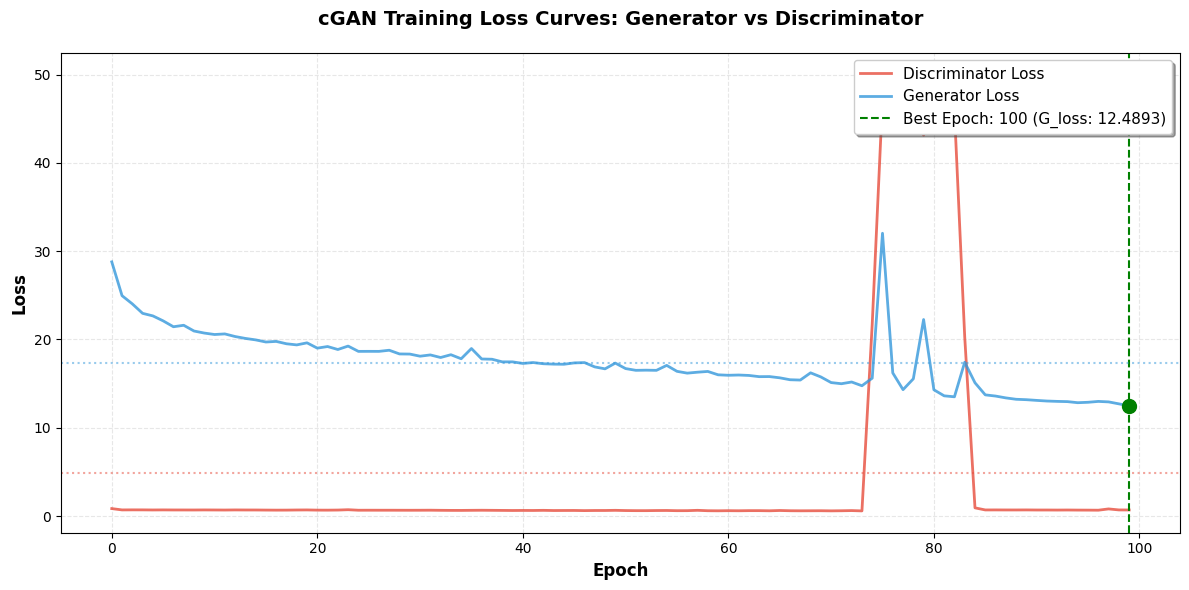


LOSS ANALYSIS
Final D Loss:   0.6881
Final G Loss:   12.4893
Best  G Loss:   12.4893  (Epoch 100)
Average D Loss: 4.8276
Average G Loss: 17.3787
Loss Ratio (G/D): 18.1515

REAL VS GENERATED IMAGE COMPARISON


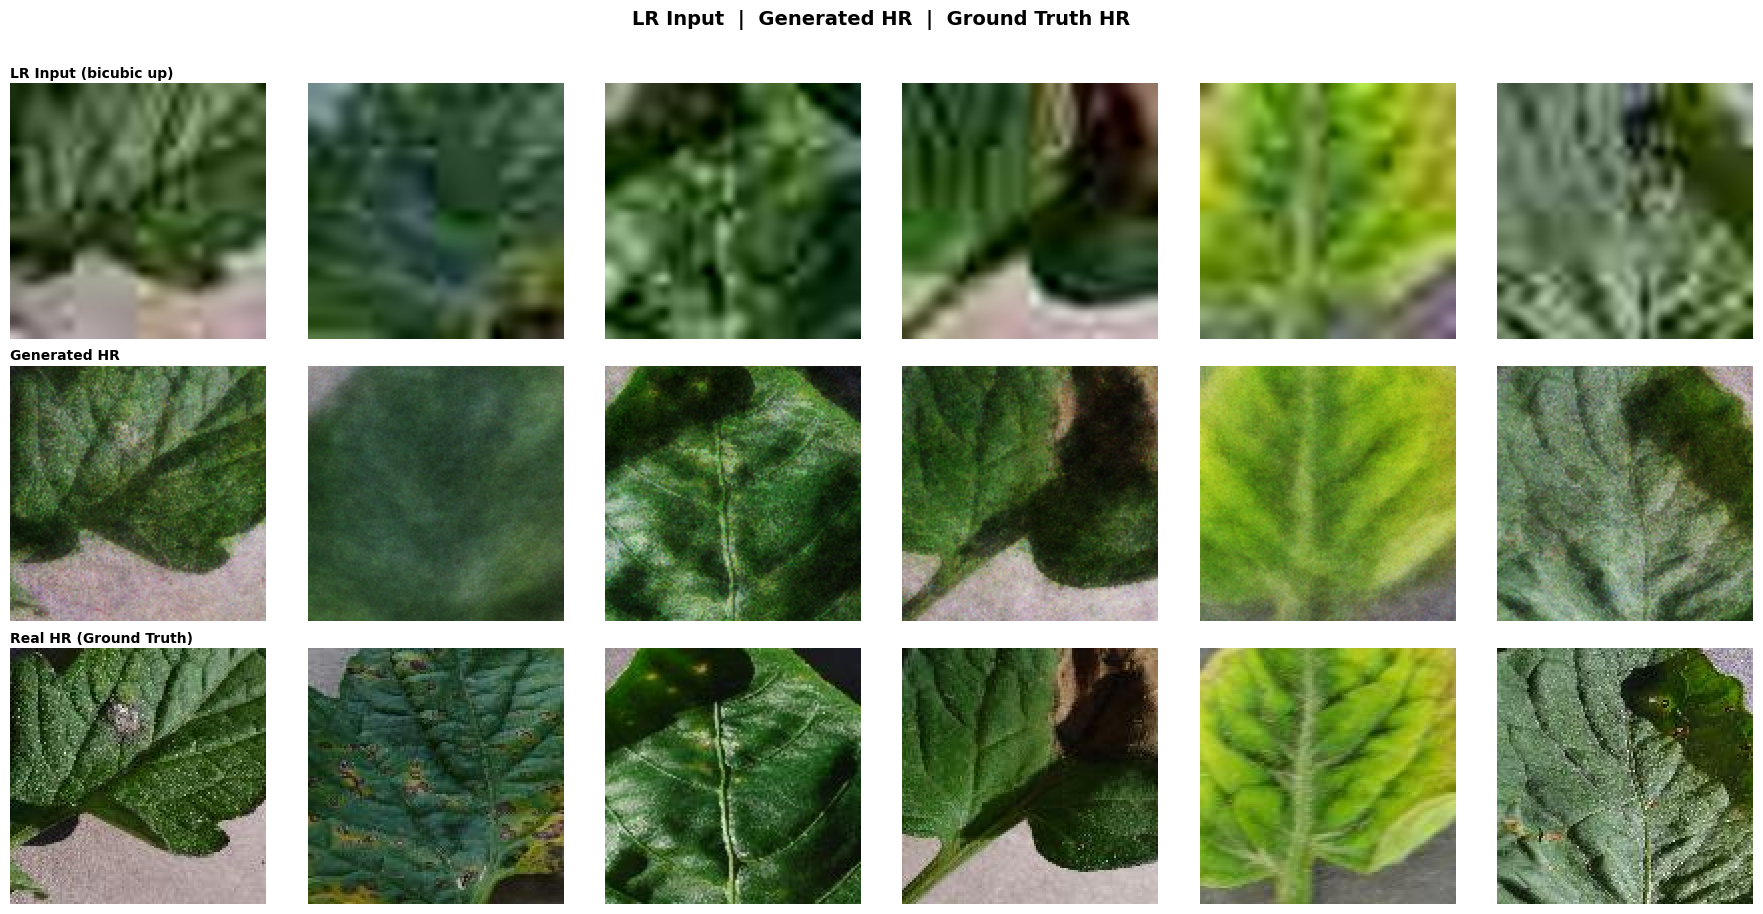


TRAINING BATCH MAE SANITY CHECK
  Image 1: MAE = 13.3001
  Image 2: MAE = 14.6291
  Image 3: MAE = 12.7641
  Image 4: MAE = 10.5339
  Image 5: MAE = 11.7427
  Image 6: MAE = 14.7921

  Average MAE on this batch: 12.9603


In [20]:
plt.figure(figsize=(12, 6))

plt.plot(d_losses, label='Discriminator Loss', linewidth=2, color='#e74c3c', alpha=0.8)
plt.plot(g_losses, label='Generator Loss',     linewidth=2, color='#3498db', alpha=0.8)


best_epoch = g_losses.index(min(g_losses))
plt.axvline(x=best_epoch, color='green', linestyle='--', linewidth=1.5,
            label=f'Best Epoch: {best_epoch+1} (G_loss: {min(g_losses):.4f})')
plt.scatter([best_epoch], [g_losses[best_epoch]], color='green', s=100, zorder=5)

plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss',  fontsize=12, fontweight='bold')
plt.title('cGAN Training Loss Curves: Generator vs Discriminator',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')

plt.axhline(y=sum(d_losses)/len(d_losses), color='#e74c3c',
            linestyle=':', alpha=0.5, label=f'Avg D Loss')
plt.axhline(y=sum(g_losses)/len(g_losses), color='#3498db',
            linestyle=':', alpha=0.5, label=f'Avg G Loss')

plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

print("\n" + "=" * 70)
print("LOSS ANALYSIS")
print("=" * 70)
print(f"Final D Loss:   {d_losses[-1]:.4f}")
print(f"Final G Loss:   {g_losses[-1]:.4f}")
print(f"Best  G Loss:   {min(g_losses):.4f}  (Epoch {best_epoch+1})")
print(f"Average D Loss: {sum(d_losses)/len(d_losses):.4f}")
print(f"Average G Loss: {sum(g_losses)/len(g_losses):.4f}")
print(f"Loss Ratio (G/D): {g_losses[-1]/d_losses[-1]:.4f}")
print("=" * 70)



print("\n" + "=" * 70)
print("REAL VS GENERATED IMAGE COMPARISON")
print("=" * 70)

generator.load_state_dict(torch.load('best_generator.pth'))
generator.eval()

sample_lr, sample_hr = next(iter(data_loader))
sample_lr = sample_lr[:6].to(device)      # take 6 samples
sample_hr = sample_hr[:6].to(device)

with torch.no_grad():
    sample_lr_flat = sample_lr.view(sample_lr.size(0), -1)
    fake_hr        = generator(sample_lr_flat)
    fake_hr        = fake_hr.view(-1, 3, HR_SIZE, HR_SIZE)

sample_lr_up = torch.nn.functional.interpolate(
    sample_lr, size=(HR_SIZE, HR_SIZE), mode='bicubic', align_corners=False
)


fig, axes = plt.subplots(3, 6, figsize=(18, 9))
titles_row = ['LR Input (bicubic up)', 'Generated HR', 'Real HR (Ground Truth)']
images_row = [
    denorm(sample_lr_up).cpu(),
    denorm(fake_hr).cpu(),
    denorm(sample_hr).cpu()
]

for row_idx, (row_title, row_imgs) in enumerate(zip(titles_row, images_row)):
    for col_idx in range(6):
        ax  = axes[row_idx][col_idx]
        img = row_imgs[col_idx].permute(1, 2, 0).numpy().clip(0, 1)
        ax.imshow(img)
        ax.axis('off')
        if col_idx == 0:
            ax.set_title(row_title, fontsize=10, fontweight='bold',
                         loc='left', pad=4)

plt.suptitle('LR Input  |  Generated HR  |  Ground Truth HR',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()



print("\n" + "=" * 70)
print("TRAINING BATCH MAE SANITY CHECK")
print("=" * 70)

with torch.no_grad():
    
    fake_255 = ((fake_hr + 1) / 2 * 255).clamp(0, 255).round()
    real_255 = ((sample_hr + 1) / 2 * 255).clamp(0, 255).round()
    mae_per_image = (fake_255 - real_255).abs().mean(dim=[1,2,3])

    for i, mae in enumerate(mae_per_image):
        print(f"  Image {i+1}: MAE = {mae.item():.4f}")
    print(f"\n  Average MAE on this batch: {mae_per_image.mean().item():.4f}")
print("=" * 70)

## 8. SUBMISSION FILE

In [21]:
print("\n" + "=" * 70)
print("GENERATING SUBMISSION CSV")
print("=" * 70)

generator.load_state_dict(torch.load('best_generator.pth'))
generator.eval()

test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

rows = []
total_images = 0

with torch.no_grad():
    for batch_idx, (lr_imgs, fnames) in enumerate(test_loader):
        lr_imgs = lr_imgs.to(device)
        lr_flat = lr_imgs.view(lr_imgs.size(0), -1)

        fake_hr      = generator(lr_flat)               
        fake_hr_imgs = fake_hr.view(-1, 3, HR_SIZE, HR_SIZE)

        for i, fname in enumerate(fnames):
            img     = fake_hr_imgs[i]                    
            img_hwc = img.permute(1, 2, 0).cpu().numpy()

            img_hwc = ((img_hwc + 1) / 2 * 255).clip(0, 255).astype(int)

            flat      = img_hwc.flatten()
            pixel_str = ' '.join(map(str, flat))
            rows.append({'Id': fname, 'Pixels': pixel_str})
            total_images += 1

        print(f"  Processed batch {batch_idx+1}/{len(test_loader)} "
              f"— {total_images} images done")

submission_df = pd.DataFrame(rows)
submission_df.to_csv('submission.csv', index=False)

print("\n" + "=" * 70)
print("SUBMISSION VALIDATION")
print("=" * 70)

pixel_counts = submission_df['Pixels'].apply(lambda x: len(x.split()))
all_correct  = (pixel_counts == 49152).all()
sample_pixels = list(map(int, submission_df['Pixels'].iloc[0].split()))
has_comma    = submission_df['Pixels'].iloc[0].find(',') != -1
has_bracket  = submission_df['Pixels'].iloc[0].find('[') != -1

print(f"Total rows:            {len(submission_df)} (expected 495)")
print(f"Pixels per row:        min={pixel_counts.min()}, max={pixel_counts.max()} (expected 49152)")
print(f"All rows correct:      {all_correct}")
print(f"Pixel value range:     min={min(sample_pixels)}, max={max(sample_pixels)}")
print(f"Columns:               {list(submission_df.columns)}")
print(f"First Id:              {submission_df['Id'].iloc[0]}")
print(f"Last Id:               {submission_df['Id'].iloc[-1]}")
print(f"No commas in pixels:   {not has_comma}")
print(f"No brackets in pixels: {not has_bracket}")

print("\n" + "=" * 70)
if all_correct and not has_comma and not has_bracket:
    print("SUBMISSION IS VALID")
else:
    print("SUBMISSION HAS ISSUES")
print("=" * 70)

print(f"\nSample entry preview:")
print(f"  Id:     {submission_df['Id'].iloc[0]}")
print(f"  Pixels: {' '.join(submission_df['Pixels'].iloc[0].split()[:20])}...")
print(f"\nSubmission is Done!")


GENERATING SUBMISSION CSV
  Processed batch 1/16 — 32 images done
  Processed batch 2/16 — 64 images done
  Processed batch 3/16 — 96 images done
  Processed batch 4/16 — 128 images done
  Processed batch 5/16 — 160 images done
  Processed batch 6/16 — 192 images done
  Processed batch 7/16 — 224 images done
  Processed batch 8/16 — 256 images done
  Processed batch 9/16 — 288 images done
  Processed batch 10/16 — 320 images done
  Processed batch 11/16 — 352 images done
  Processed batch 12/16 — 384 images done
  Processed batch 13/16 — 416 images done
  Processed batch 14/16 — 448 images done
  Processed batch 15/16 — 480 images done
  Processed batch 16/16 — 495 images done

SUBMISSION VALIDATION
Total rows:            495 (expected 495)
Pixels per row:        min=49152, max=49152 (expected 49152)
All rows correct:      True
Pixel value range:     min=2, max=223
Columns:               ['Id', 'Pixels']
First Id:              agrivision_test_0000.png
Last Id:               agrivision